#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Dataset

In [2]:
df = pd.read_csv("healthcare_dataset[1].csv")

#### Dataset Understanding

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.shape

(55500, 15)

In [5]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [6]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [7]:
df.dtypes

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

#### Exploratory Data Analysis

In [8]:
# Shape of Dataset

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 55500
Number of Columns : 15


In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [10]:
# Missing Values

missing_values = df.isnull().sum()

print("Missing Values in Each Column")
print(missing_values)

Missing Values in Each Column
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


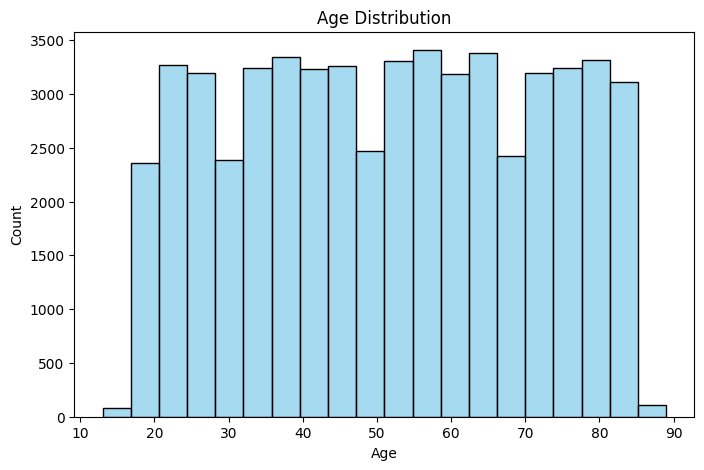

In [11]:
# age distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, color="skyblue")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

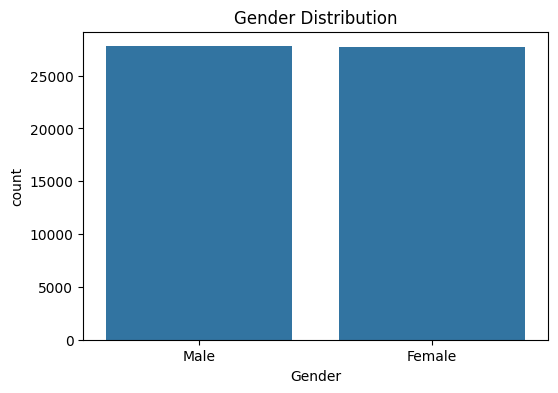

In [12]:
# gender distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

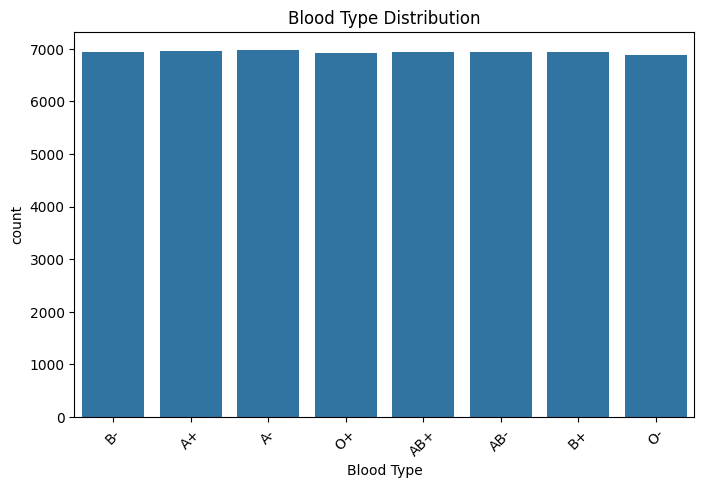

In [13]:
# blood type distribution

plt.figure(figsize=(8,5))

sns.countplot(x="Blood Type", data=df)

plt.title("Blood Type Distribution")

plt.xticks(rotation=45)

plt.show()

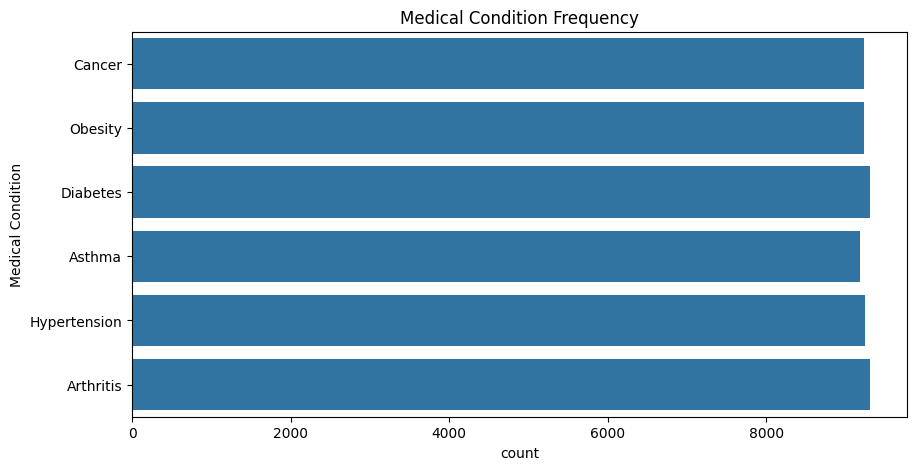

In [14]:
# medical condition frequency

plt.figure(figsize=(10,5))

sns.countplot(y="Medical Condition", data=df)

plt.title("Medical Condition Frequency")

plt.show()

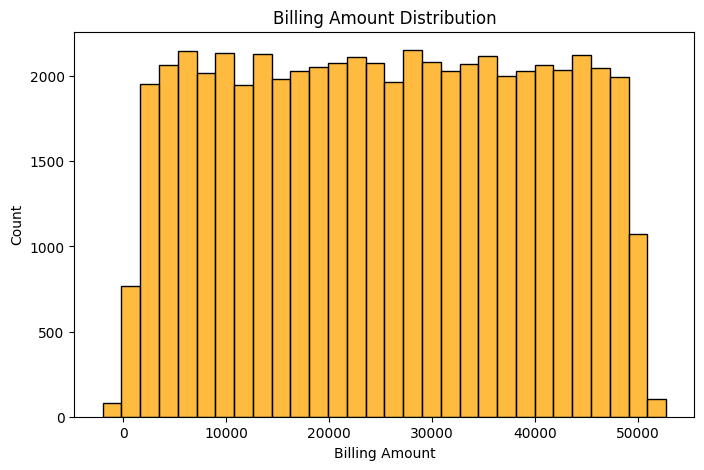

In [15]:
# billing amount distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Billing Amount"], bins=30, color="orange")

plt.title("Billing Amount Distribution")

plt.xlabel("Billing Amount")

plt.show()

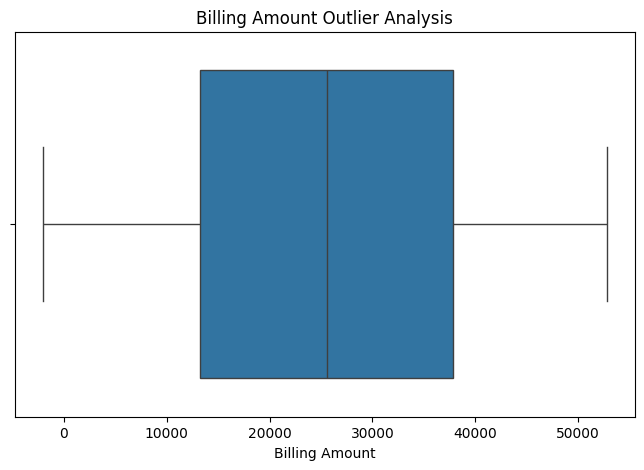

In [16]:
# billing amount outliers

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Billing Amount"])

plt.title("Billing Amount Outlier Analysis")

plt.show()

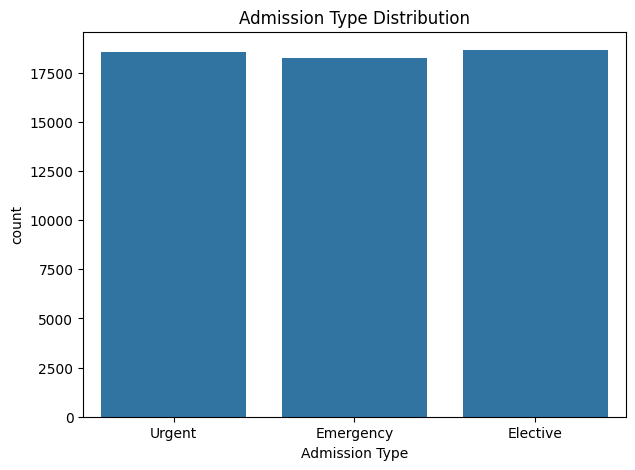

In [17]:
# admission type distribution

plt.figure(figsize=(7,5))

sns.countplot(x="Admission Type", data=df)

plt.title("Admission Type Distribution")

plt.show()

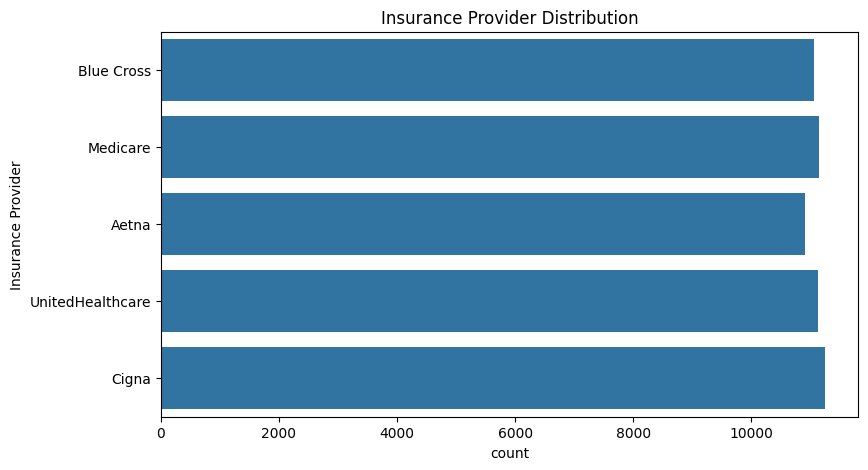

In [18]:
# insurance provider distribution

plt.figure(figsize=(9,5))

sns.countplot(y="Insurance Provider", data=df)

plt.title("Insurance Provider Distribution")

plt.show()

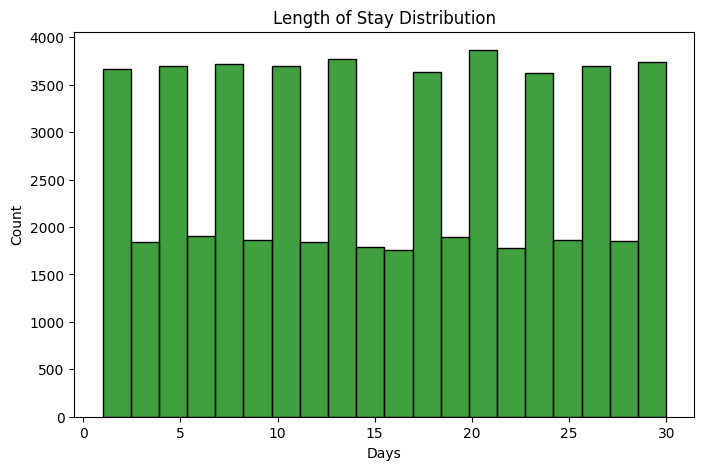

In [19]:
# length of stay analysis

# Convert into datetime

df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])

df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

# Create New Column

df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

# Plot

plt.figure(figsize=(8,5))

sns.histplot(df["Length of Stay"], bins=20, color="green")

plt.title("Length of Stay Distribution")

plt.xlabel("Days")

plt.show()

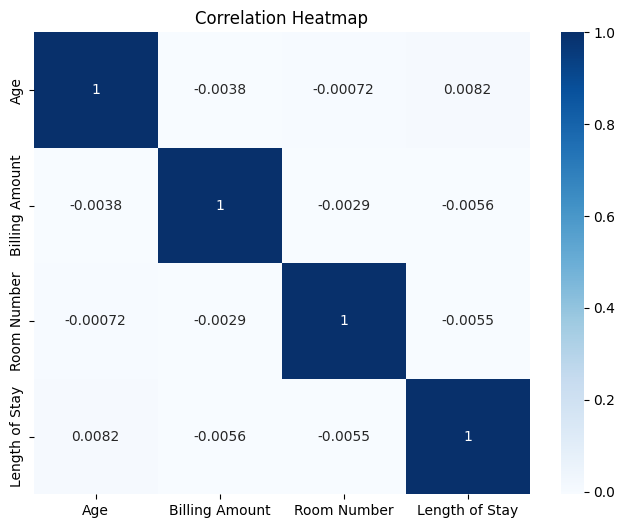

In [20]:
# correlation analysis

# Select Numerical Columns

num_df = df.select_dtypes(include=["int64","float64"])

# Correlation Matrix

corr = num_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

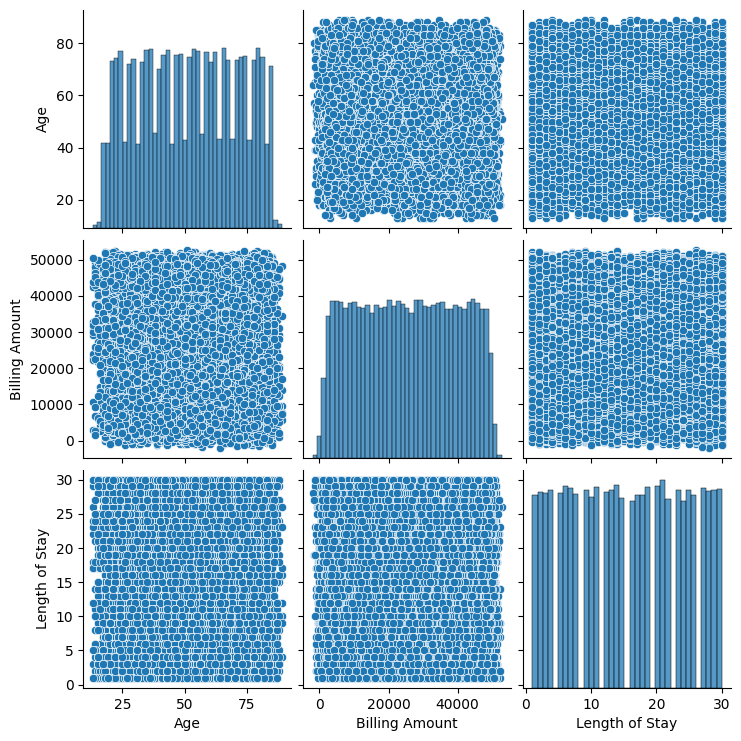

In [21]:
sns.pairplot(df[["Age","Billing Amount","Length of Stay"]])

plt.show()

#### Data Preperation

In [22]:
# Check Missing Values

print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
dtype: int64


In [23]:
# Fill Missing Values if any exist...

for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing Values Filled")

Missing Values Filled


C:\Users\saini\AppData\Local\Temp\ipykernel_15312\3808657082.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\saini\AppData\Local\Temp\ipykernel_15312\3808657082.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [24]:
# Convert Date Columns

df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

# Create New Feature

df["Length of Stay"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

df[["Date of Admission","Discharge Date","Length of Stay"]].head()

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [25]:
# Drop Columns

df = df.drop(
    columns=[
        "Name",
        "Doctor",
        "Hospital",
        "Room Number",
        "Date of Admission",
        "Discharge Date"
    ]
)

df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,2
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,15
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,20


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length of Stay
0,30,1,5,2,1,18856.281306,2,3,2,2
1,62,1,0,5,3,33643.327287,1,1,1,6
2,76,0,1,5,0,27955.096079,1,0,2,15
3,28,0,6,3,3,37909.782410,0,1,0,30
4,43,0,2,2,0,14238.317814,2,4,0,20


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_data

array([[-1.09882435,  0.99913551,  0.65834792, ...,  0.70897543,
         1.22479483, -1.56001783],
       [ 0.53363905,  0.99913551, -1.52536431, ..., -0.70622153,
         0.00242272, -1.09809858],
       [ 1.24784178, -1.00086524, -1.08862186, ..., -1.41382001,
         1.22479483, -0.05878027],
       ...,
       [-0.6907085 , -1.00086524,  0.22160548, ..., -0.70622153,
        -1.21994939,  1.4424573 ],
       [-0.43563609,  0.99913551,  1.53183282, ..., -0.70622153,
        -1.21994939, -1.09809858],
       [ 0.07450872, -1.00086524,  1.09509037, ..., -0.70622153,
        -1.21994939,  1.32697749]], shape=(55500, 10))

In [28]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length of Stay
0,-1.098824,0.999136,0.658348,-0.292010,-0.715785,-0.470261,1.222679,0.708975,1.224795,-1.560018
1,0.533639,0.999136,-1.525364,1.464101,0.702522,0.570250,0.001738,-0.706222,0.002423,-1.098099
2,1.247842,-1.000865,-1.088622,1.464101,-1.424939,0.169990,0.001738,-1.413820,1.224795,-0.058780
3,-1.200853,-1.000865,1.095090,0.293360,0.702522,0.870465,-1.219203,-0.706222,-1.219949,1.673417
4,-0.435636,-1.000865,-0.651879,-0.292010,-1.424939,-0.795211,1.222679,1.416574,-1.219949,0.518619


In [29]:
# PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

pca_data[:5]

array([[ 0.56742093,  2.02984874],
       [ 1.08342015,  0.92628665],
       [ 1.22726745, -1.22886651],
       [ 0.34372165, -1.47221335],
       [-0.6724763 , -0.14955442]])

In [30]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df.head()

,PC1,PC2
0,0.567421,2.029849
1,1.083420,0.926287
2,1.227267,-1.228867
3,0.343722,-1.472213
4,-0.672476,-0.149554


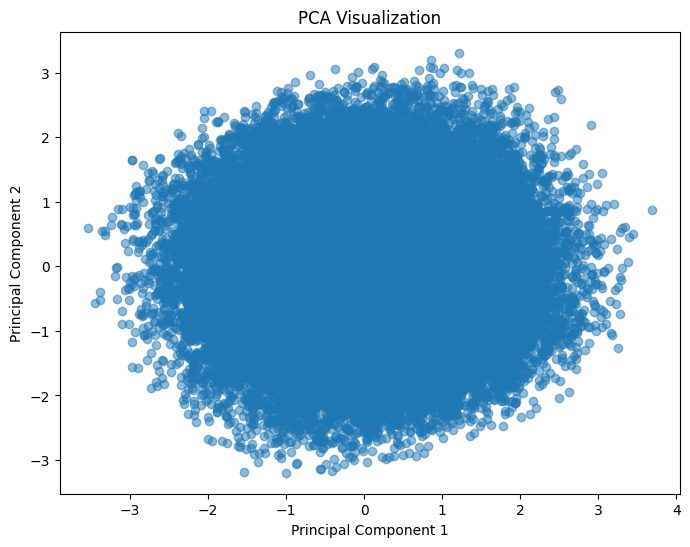

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.title("PCA Visualization")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

#### Models

In [33]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

In [35]:
# K means

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_df)

print(kmeans_labels[:10])

[3 0 2 1 2 3 2 2 0 2]


In [36]:
# Hierarichial Clustering

hc = AgglomerativeClustering(
    n_clusters=4
)

hc_labels = hc.fit_predict(scaled_df)

print(hc_labels[:10])

[0 1 3 2 2 0 3 2 1 3]


In [37]:
# DBScan

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(scaled_df)

print(dbscan_labels[:10])

[0 0 1 1 1 0 1 1 0 1]


In [38]:
# gmm

gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm.fit(scaled_df)

gmm_labels = gmm.predict(scaled_df)

print(gmm_labels[:10])

[1 3 0 2 2 1 2 2 3 0]


In [39]:
# adding clusters lacels

df["KMeans"] = kmeans_labels
df["Hierarchical"] = hc_labels
df["DBSCAN"] = dbscan_labels
df["GMM"] = gmm_labels

df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length of Stay,KMeans,Hierarchical,DBSCAN,GMM
0,30,1,5,2,1,18856.281306,2,3,2,2,3,0,0,1
1,62,1,0,5,3,33643.327287,1,1,1,6,0,1,0,3
2,76,0,1,5,0,27955.096079,1,0,2,15,2,3,1,0
3,28,0,6,3,3,37909.782410,0,1,0,30,1,2,1,2
4,43,0,2,2,0,14238.317814,2,4,0,20,2,2,1,2


In [40]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [41]:
# elbow method

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)

    wcss.append(model.inertia_)

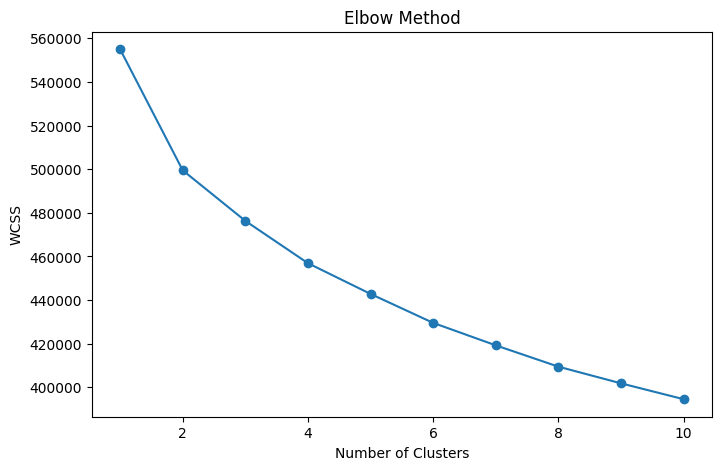

In [42]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [43]:
# silhouette score

print("K-Means Silhouette Score")
print(silhouette_score(scaled_df, kmeans_labels))

K-Means Silhouette Score
0.0815665040841379


In [44]:
print("Hierarchical Silhouette Score")
print(silhouette_score(scaled_df, hc_labels))

Hierarchical Silhouette Score
0.03932587942881797


In [47]:
# DBSCAN 

if len(set(dbscan_labels)) > 1 and -1 in dbscan_labels:
    
    print("DBSCAN Silhouette Score")
    print(silhouette_score(scaled_df, dbscan_labels))

else:
    
    print("Silhouette Score cannot be calculated for DBSCAN.")

Silhouette Score cannot be calculated for DBSCAN.


In [46]:
print("GMM Silhouette Score")
print(silhouette_score(scaled_df, gmm_labels))

GMM Silhouette Score
0.08042207836577792


In [48]:
# Davies boulin index

print("K-Means DB Index")
print(davies_bouldin_score(scaled_df, kmeans_labels))

K-Means DB Index
3.238411701992778


In [49]:
print("Hierarchical DB Index")
print(davies_bouldin_score(scaled_df, hc_labels))

Hierarchical DB Index
4.798072651576686


In [50]:
print("GMM DB Index")
print(davies_bouldin_score(scaled_df, gmm_labels))

GMM DB Index
3.2643158290624097


In [51]:
labels = dbscan_labels

valid = labels != -1

if len(set(labels[valid])) > 1:
    
    print(davies_bouldin_score(
        scaled_df[valid],
        labels[valid]
    ))

else:
    
    print("DB Index cannot be calculated.")

2.9684677122697884


In [ ]:
# dendogram analysis

linked = linkage(
    scaled_df,
    method="ward"
)

In [ ]:
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Patients")

plt.ylabel("Distance")

plt.show()

In [ ]:
# comparision table

results = {
    "Model": ["K-Means", "Hierarchical", "GMM"],
    "Silhouette Score": [
        silhouette_score(scaled_df, kmeans_labels),
        silhouette_score(scaled_df, hc_labels),
        silhouette_score(scaled_df, gmm_labels)
    ],
    "Davies-Bouldin Index": [
        davies_bouldin_score(scaled_df, kmeans_labels),
        davies_bouldin_score(scaled_df, hc_labels),
        davies_bouldin_score(scaled_df, gmm_labels)
    ]
}

comparison = pd.DataFrame(results)

comparison

#### cluster profiling and inrerpretation